In [1]:
from langgraph.graph import Graph, END, START

In [2]:
## Workflow
workflow = Graph()

In [3]:
## supervisor function
def supervisor_func(state):
    pass

In [4]:
## llm function
def llm_func(state):
    pass

In [5]:
## RAG function
def rag_func(state):
    pass

In [6]:
## web_crawler function
def web_crawler_func(state):
    pass

In [7]:
## Router function
def router(state):
    pass

In [8]:
## Validation function
def validation_func(state):
    pass

In [9]:
## Validation router
def validation_router(state):
    pass

In [10]:
workflow.add_node('supervisor', supervisor_func)
workflow.add_node('llm', llm_func)
workflow.add_node('crawler', web_crawler_func)
workflow.add_node('rag', rag_func)
workflow.add_node('validation', validation_func)

In [11]:
workflow.add_edge(START, 'supervisor')
workflow.add_conditional_edges(
    'supervisor',
    router,
    {
        'RAG Call': 'rag',
        'LLM Call': 'llm',
        'Crawler Call': 'crawler'
    }
)
workflow.add_edge('rag', 'validation')
workflow.add_edge('llm', 'validation')
workflow.add_edge('crawler', 'validation')

In [12]:
workflow.add_conditional_edges(
    'validation',
    validation_router,
    {
        'Supervisor call': 'supervisor',
        'END call': END
    }
)

In [13]:
app = workflow.compile()

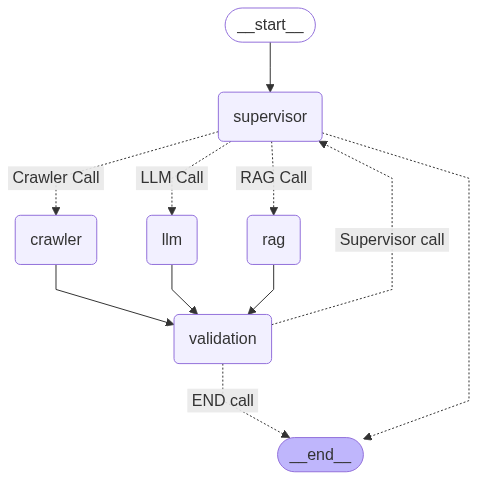

In [14]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))